# TIỀN XỬ LÝ ẢNH - PLANT DISEASE CLASSIFICATION

Notebook này thực hiện các kỹ thuật tiền xử lý ảnh và phân tích tác động của chúng đến hiệu suất phân loại bệnh cây trồng.

## Nội dung:
0. Setup và Import thư viện
1. Thiết lập Baseline (Mô hình cơ sở)
2. Các kỹ thuật tiền xử lý:
   - a) Thay đổi kích thước và chất lượng ảnh (SSIM & PSNR)
   - b) Chuyển đổi không gian màu (Color Space & PCA Explained Variance)
   - c) Chuẩn hóa (Normalization & KS Test)
   - d) Tăng cường dữ liệu (Data Augmentation & t-SNE)

---
## 0. Setup và Import thư viện

In [41]:
# Thư viện cơ bản
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import gc
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Thư viện xử lý ảnh
import cv2
from PIL import Image
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

# Thư viện Machine Learning
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.manifold import TSNE

# Thư viện kiểm định thống kê
from scipy import stats
from scipy.stats import kstest, norm

# Cấu hình hiển thị
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
np.random.seed(42)

print("Import thành công!")

Import thành công!


In [42]:
# Cấu hình đường dẫn
DATA_DIR = Path('../data/raw/lab_2.1_NewPlantDiseasesDataset/class_folders')
RANDOM_STATE = 42
BATCH_SIZE = 500  # Kích thước lô để tránh tràn RAM
N_COMPONENTS_PCA = 50  # Số thành phần PCA

# Kiểm tra cấu trúc thư mục
class_names = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
print(f"Số lớp: {len(class_names)}")
print(f"Các lớp: {class_names}")

Số lớp: 5
Các lớp: ['Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___healthy']


In [43]:
# Đếm số ảnh mỗi lớp
class_counts = {}
all_image_paths = []
all_labels = []

for class_name in class_names:
    class_dir = DATA_DIR / class_name
    images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.JPG'))
    class_counts[class_name] = len(images)
    for img_path in images:
        all_image_paths.append(img_path)
        all_labels.append(class_name)

print("Số lượng ảnh mỗi lớp:")
for name, count in class_counts.items():
    print(f"  {name}: {count}")
print(f"\nTổng số ảnh: {len(all_image_paths)}")

Số lượng ảnh mỗi lớp:
  Tomato___Bacterial_spot: 1109
  Tomato___Early_blight: 1236
  Tomato___Late_blight: 1185
  Tomato___Leaf_Mold: 1221
  Tomato___healthy: 1249

Tổng số ảnh: 6000


In [44]:
# Mã hóa nhãn
label_encoder = LabelEncoder()
encoded_labels = label_encoder.fit_transform(all_labels)

# Chia train/test (80/20) - giữ cố định để đảm bảo tính công bằng
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_image_paths, 
    encoded_labels, 
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=encoded_labels
)

print(f"Tập train: {len(train_paths)} ảnh")
print(f"Tập test: {len(test_paths)} ảnh")

Tập train: 4800 ảnh
Tập test: 1200 ảnh


---
## Hàm tiện ích xử lý theo batch

In [45]:
def load_and_resize_image(img_path, target_size=(64, 64)):
    """
    Đọc và resize ảnh về kích thước mong muốn.
    
    Parameters:
    -----------
    img_path : Path
        Đường dẫn đến file ảnh
    target_size : tuple
        Kích thước mong muốn (width, height)
    
    Returns:
    --------
    numpy.ndarray: Ảnh đã resize
    """
    img = cv2.imread(str(img_path))
    if img is None:
        return None
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Chuyển từ BGR sang RGB
    img_resized = cv2.resize(img, target_size, interpolation=cv2.INTER_LINEAR)
    return img_resized


def load_images_in_batches(image_paths, target_size=(64, 64), batch_size=500):
    """
    Generator để đọc ảnh theo lô (batch) để tiết kiệm RAM.
    
    Yields:
    -------
    numpy.ndarray: Mảng ảnh của batch hiện tại
    list: Danh sách chỉ số của ảnh trong batch
    """
    for i in range(0, len(image_paths), batch_size):
        batch_paths = image_paths[i:i+batch_size]
        batch_images = []
        batch_indices = []
        
        for j, path in enumerate(batch_paths):
            img = load_and_resize_image(path, target_size)
            if img is not None:
                batch_images.append(img)
                batch_indices.append(i + j)
        
        if batch_images:
            yield np.array(batch_images), batch_indices


def flatten_images(images):
    """
    Làm phẳng mảng ảnh từ (n, h, w, c) thành (n, h*w*c)
    """
    n_samples = images.shape[0]
    return images.reshape(n_samples, -1)


print("Các hàm tiện ích đã được định nghĩa!")

Các hàm tiện ích đã được định nghĩa!


---
## 1. Thiết lập Baseline 

Baseline là mô hình cơ sở dùng để làm mốc so sánh hiệu suất. Pipeline baseline:
1. Đọc ảnh và resize về 64x64
2. Làm phẳng (Flatten) ảnh thành vector
3. Áp dụng IncrementalPCA với k=50 thành phần để giảm chiều
4. Train Logistic Regression và đánh giá

**Sử dụng IncrementalPCA thay vì PCA để tránh tràn RAM:**
- Đọc ảnh theo từng lô (batch) 500 ảnh
- Gọi `.partial_fit()` cho mỗi lô
- Mô hình cập nhật dần các thành phần chính

In [46]:
# Bước 1: Đọc và xử lý ảnh train theo batch, sau đó fit IncrementalPCA
print("=" * 60)
print("THIẾT LẬP BASELINE")
print("=" * 60)

TARGET_SIZE = (64, 64)  # Resize xuống 64x64 để giảm bộ nhớ
N_FEATURES = TARGET_SIZE[0] * TARGET_SIZE[1] * 3  # 64 * 64 * 3 = 12288 chiều

print(f"\nKích thước ảnh mục tiêu: {TARGET_SIZE}")
print(f"Số chiều sau khi flatten: {N_FEATURES}")
print(f"Ước tính bộ nhớ cho ma trận (6000, 12288): {6000 * 12288 * 8 / 1024 / 1024:.2f} MB")

# Khởi tạo IncrementalPCA
ipca_baseline = IncrementalPCA(n_components=N_COMPONENTS_PCA)

# Fit IncrementalPCA trên tập train theo batch
print(f"\nĐang fit IncrementalPCA với batch_size={BATCH_SIZE}...")
n_batches = 0
for batch_images, batch_indices in load_images_in_batches(train_paths, TARGET_SIZE, BATCH_SIZE):
    batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0  # Chuẩn hóa [0,1]
    ipca_baseline.partial_fit(batch_flat)
    n_batches += 1
    print(f"  Batch {n_batches}: {len(batch_indices)} ảnh")
    
    # Giải phóng bộ nhớ
    del batch_images, batch_flat
    gc.collect()

print(f"\nHoàn thành fit PCA!")
print(f"Tổng phương sai giải thích (k={N_COMPONENTS_PCA}): {np.sum(ipca_baseline.explained_variance_ratio_)*100:.2f}%")

THIẾT LẬP BASELINE

Kích thước ảnh mục tiêu: (64, 64)
Số chiều sau khi flatten: 12288
Ước tính bộ nhớ cho ma trận (6000, 12288): 562.50 MB

Đang fit IncrementalPCA với batch_size=500...
  Batch 1: 500 ảnh
  Batch 2: 500 ảnh
  Batch 3: 500 ảnh
  Batch 4: 500 ảnh
  Batch 5: 500 ảnh
  Batch 6: 500 ảnh
  Batch 7: 500 ảnh
  Batch 8: 500 ảnh
  Batch 9: 500 ảnh
  Batch 10: 300 ảnh

Hoàn thành fit PCA!
Tổng phương sai giải thích (k=50): 74.98%


In [47]:
# Bước 2: Transform dữ liệu train và test
print("\nĐang transform dữ liệu train...")

# Transform train data
X_train_pca_list = []
for batch_images, batch_indices in load_images_in_batches(train_paths, TARGET_SIZE, BATCH_SIZE):
    batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
    batch_pca = ipca_baseline.transform(batch_flat)
    X_train_pca_list.append(batch_pca)
    
    del batch_images, batch_flat
    gc.collect()

X_train_pca = np.vstack(X_train_pca_list)
y_train = train_labels[:len(X_train_pca)]
del X_train_pca_list
gc.collect()

print(f"X_train_pca shape: {X_train_pca.shape}")

# Transform test data
print("Đang transform dữ liệu test...")
X_test_pca_list = []

for batch_images, batch_indices in load_images_in_batches(test_paths, TARGET_SIZE, BATCH_SIZE):
    batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
    batch_pca = ipca_baseline.transform(batch_flat)
    X_test_pca_list.append(batch_pca)
    
    del batch_images, batch_flat
    gc.collect()

X_test_pca = np.vstack(X_test_pca_list)
y_test = test_labels[:len(X_test_pca)]
del X_test_pca_list
gc.collect()

print(f"X_test_pca shape: {X_test_pca.shape}")


Đang transform dữ liệu train...
X_train_pca shape: (4800, 50)
Đang transform dữ liệu test...
X_test_pca shape: (1200, 50)


In [48]:
# Bước 3: Train và đánh giá Logistic Regression
print("\nĐang train Logistic Regression...")

lr_baseline = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE,
    solver='lbfgs'
)
lr_baseline.fit(X_train_pca, y_train)

# Dự đoán và đánh giá
y_pred_baseline = lr_baseline.predict(X_test_pca)

baseline_accuracy = accuracy_score(y_test, y_pred_baseline)
baseline_f1 = f1_score(y_test, y_pred_baseline, average='weighted')

print("\n" + "=" * 60)
print("KẾT QUẢ BASELINE")
print("=" * 60)
print(f"Accuracy: {baseline_accuracy:.4f} ({baseline_accuracy*100:.2f}%)")
print(f"F1-Score (weighted): {baseline_f1:.4f} ({baseline_f1*100:.2f}%)")
print(f"\nPhương sai giải thích bởi PCA: {np.sum(ipca_baseline.explained_variance_ratio_)*100:.2f}%")


Đang train Logistic Regression...

KẾT QUẢ BASELINE
Accuracy: 0.6717 (67.17%)
F1-Score (weighted): 0.6671 (66.71%)

Phương sai giải thích bởi PCA: 74.98%


In [49]:
# Hiển thị chi tiết kết quả phân loại
print("\nBáo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred_baseline, target_names=label_encoder.classes_))


Báo cáo phân loại chi tiết:
                         precision    recall  f1-score   support

Tomato___Bacterial_spot       0.68      0.80      0.74       222
  Tomato___Early_blight       0.60      0.53      0.56       247
   Tomato___Late_blight       0.53      0.48      0.51       237
     Tomato___Leaf_Mold       0.76      0.76      0.76       244
       Tomato___healthy       0.75      0.79      0.77       250

               accuracy                           0.67      1200
              macro avg       0.67      0.67      0.67      1200
           weighted avg       0.67      0.67      0.67      1200



In [50]:
# Lưu kết quả baseline
results_baseline = {
    'method': 'Baseline (64x64, MinMax[0,1], PCA-50)',
    'accuracy': baseline_accuracy,
    'f1_score': baseline_f1,
    'explained_variance': np.sum(ipca_baseline.explained_variance_ratio_)
}

# Danh sách lưu tất cả kết quả để so sánh
all_results = [results_baseline]

print("Đã lưu kết quả baseline!")

Đã lưu kết quả baseline!


### Nhận xét kết quả Baseline (theo số liệu thực nghiệm)

- **Accuracy = 0.6717**, **F1-weighted = 0.6671** với pipeline `64x64 + MinMax[0,1] + PCA-50 + LogisticRegression`.
- Chênh lệch nhỏ giữa Accuracy và F1 cho thấy mô hình chưa bị lệch nghiêm trọng theo lớp lớn, nhưng vẫn còn dư địa cải thiện khả năng phân loại đồng đều giữa các lớp.
- Đây là mốc hợp lý để so sánh các kỹ thuật tiền xử lý phía sau: kỹ thuật nào cải thiện đáng kể so với mức ~0.67 mới được xem là có tác động thực sự.

**Ý nghĩa:** Baseline hiện tại không tệ, nên các cải tiến nhỏ (<0.5%) cần cân nhắc thêm chi phí tính toán trước khi kết luận là tốt hơn.

---
## 2a. Thay đổi kích thước và chất lượng ảnh (SSIM & PSNR)

**SSIM (Structural Similarity Index):**
- Đo tương đồng cấu trúc giữa 2 ảnh
- Giá trị từ -1 đến 1, càng gần 1 càng giống
- Công thức: $SSIM(x,y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$

**PSNR (Peak Signal-to-Noise Ratio):**
- Đo tỷ lệ tín hiệu trên nhiễu (đơn vị dB)
- Càng cao càng tốt, thường > 30dB là chấp nhận được
- Công thức: $PSNR = 10 \cdot \log_{10}\left(\frac{MAX_I^2}{MSE}\right)$

**Mục tiêu:** Tìm điểm cân bằng giữa giữ lại chi tiết cấu trúc vết bệnh và giảm khối lượng tính toán.

In [51]:
print("=" * 60)
print("PHẦN 2a: THAY ĐỔI KÍCH THƯỚC ẢNH (SSIM & PSNR)")
print("=" * 60)

# Các kích thước cần kiểm tra
resize_sizes = [32, 64, 128]
original_size = 256  # Giả sử ảnh gốc là 256x256

# Lấy mẫu ảnh để tính SSIM và PSNR (500 ảnh để tiết kiệm thời gian)
sample_size = 500
np.random.seed(RANDOM_STATE)
sample_indices = np.random.choice(len(train_paths), min(sample_size, len(train_paths)), replace=False)
sample_paths = [train_paths[i] for i in sample_indices]

print(f"Số ảnh mẫu để tính SSIM/PSNR: {len(sample_paths)}")

PHẦN 2a: THAY ĐỔI KÍCH THƯỚC ẢNH (SSIM & PSNR)
Số ảnh mẫu để tính SSIM/PSNR: 500


In [52]:
def compute_ssim_psnr_for_size(image_paths, target_size, ref_size=256):
    """
    Tính SSIM và PSNR trung bình khi resize ảnh xuống kích thước target_size,
    sau đó phóng to lại về ref_size để so sánh với ảnh gốc.
    
    Parameters:
    -----------
    image_paths : list
        Danh sách đường dẫn ảnh
    target_size : int
        Kích thước cần resize (vd: 64)
    ref_size : int
        Kích thước ảnh gốc (vd: 256)
    
    Returns:
    --------
    tuple: (mean_ssim, mean_psnr, std_ssim, std_psnr)
    """
    ssim_values = []
    psnr_values = []
    
    for path in image_paths:
        # Đọc ảnh gốc
        img_original = cv2.imread(str(path))
        if img_original is None:
            continue
        img_original = cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB)
        
        # Resize về kích thước chuẩn (256x256) để có thể so sánh
        img_ref = cv2.resize(img_original, (ref_size, ref_size), interpolation=cv2.INTER_LINEAR)
        
        # Resize xuống target_size
        img_small = cv2.resize(img_ref, (target_size, target_size), interpolation=cv2.INTER_LINEAR)
        
        # Phóng to lại về ref_size (để so sánh được)
        img_upscaled = cv2.resize(img_small, (ref_size, ref_size), interpolation=cv2.INTER_LINEAR)
        
        # Tính SSIM
        ssim_val = ssim(img_ref, img_upscaled, channel_axis=2, data_range=255)
        ssim_values.append(ssim_val)
        
        # Tính PSNR
        psnr_val = psnr(img_ref, img_upscaled, data_range=255)
        psnr_values.append(psnr_val)
    
    return (np.mean(ssim_values), np.mean(psnr_values), 
            np.std(ssim_values), np.std(psnr_values))


# Tính SSIM và PSNR cho các kích thước khác nhau
print("\nĐang tính SSIM và PSNR cho các kích thước...")
resize_metrics = {}

for size in resize_sizes:
    print(f"  Đang xử lý kích thước {size}x{size}...")
    mean_ssim, mean_psnr, std_ssim, std_psnr = compute_ssim_psnr_for_size(
        sample_paths, size, original_size
    )
    resize_metrics[size] = {
        'ssim_mean': mean_ssim,
        'ssim_std': std_ssim,
        'psnr_mean': mean_psnr,
        'psnr_std': std_psnr
    }
    print(f"    SSIM: {mean_ssim:.4f} +/- {std_ssim:.4f}")
    print(f"    PSNR: {mean_psnr:.2f} +/- {std_psnr:.2f} dB")

gc.collect()


Đang tính SSIM và PSNR cho các kích thước...
  Đang xử lý kích thước 32x32...
    SSIM: 0.4343 +/- 0.1648
    PSNR: 23.23 +/- 3.65 dB
  Đang xử lý kích thước 64x64...
    SSIM: 0.5401 +/- 0.1626
    PSNR: 25.06 +/- 4.05 dB
  Đang xử lý kích thước 128x128...
    SSIM: 0.6788 +/- 0.1442
    PSNR: 27.11 +/- 4.58 dB


0

In [53]:
def evaluate_with_resize(train_paths, test_paths, train_labels, test_labels, 
                         target_size, batch_size=500, n_components=50):
    """
    Đánh giá hiệu suất phân loại với kích thước ảnh cho trước.
    Sử dụng IncrementalPCA để tránh tràn RAM.
    
    Returns:
    --------
    dict: Kết quả accuracy, f1_score, explained_variance
    """
    # Fit IncrementalPCA
    ipca = IncrementalPCA(n_components=n_components)
    
    for batch_images, _ in load_images_in_batches(train_paths, (target_size, target_size), batch_size):
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        ipca.partial_fit(batch_flat)
        del batch_images, batch_flat
        gc.collect()
    
    # Transform train
    X_train_list = []
    for batch_images, batch_indices in load_images_in_batches(train_paths, (target_size, target_size), batch_size):
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        X_train_list.append(ipca.transform(batch_flat))
        del batch_images, batch_flat
        gc.collect()
    X_train = np.vstack(X_train_list)
    del X_train_list
    gc.collect()
    
    # Transform test
    X_test_list = []
    for batch_images, _ in load_images_in_batches(test_paths, (target_size, target_size), batch_size):
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        X_test_list.append(ipca.transform(batch_flat))
        del batch_images, batch_flat
        gc.collect()
    X_test = np.vstack(X_test_list)
    del X_test_list
    gc.collect()
    
    # Điều chỉnh độ dài nhãn
    y_train_adj = train_labels[:len(X_train)]
    y_test_adj = test_labels[:len(X_test)]
    
    # Train và đánh giá
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_train, y_train_adj)
    y_pred = lr.predict(X_test)
    
    accuracy = accuracy_score(y_test_adj, y_pred)
    f1 = f1_score(y_test_adj, y_pred, average='weighted')
    exp_var = np.sum(ipca.explained_variance_ratio_)
    
    # Giải phóng bộ nhớ
    del X_train, X_test, ipca, lr
    gc.collect()
    
    return {'accuracy': accuracy, 'f1_score': f1, 'explained_variance': exp_var}


# Ablation Study: Đánh giá hiệu suất với các kích thước khác nhau
print("\n" + "-" * 60)
print("ABLATION STUDY: KÍCH THƯỚC ẢNH")
print("-" * 60)

resize_results = {}

for size in resize_sizes:
    print(f"\nĐang đánh giá với kích thước {size}x{size}...")
    result = evaluate_with_resize(
        train_paths, test_paths, train_labels, test_labels,
        target_size=size, batch_size=BATCH_SIZE, n_components=N_COMPONENTS_PCA
    )
    resize_results[size] = result
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1_score']:.4f}")
    print(f"  Explained Variance: {result['explained_variance']*100:.2f}%")


------------------------------------------------------------
ABLATION STUDY: KÍCH THƯỚC ẢNH
------------------------------------------------------------

Đang đánh giá với kích thước 32x32...
  Accuracy: 0.6675
  F1-Score: 0.6618
  Explained Variance: 75.34%

Đang đánh giá với kích thước 64x64...
  Accuracy: 0.6717
  F1-Score: 0.6671
  Explained Variance: 74.98%

Đang đánh giá với kích thước 128x128...
  Accuracy: 0.6742
  F1-Score: 0.6684
  Explained Variance: 74.97%


In [54]:
# Tạo bảng tổng hợp kết quả
resize_df = pd.DataFrame({
    'Kich thuoc': [f"{s}x{s}" for s in resize_sizes],
    'SSIM': [resize_metrics[s]['ssim_mean'] for s in resize_sizes],
    'PSNR (dB)': [resize_metrics[s]['psnr_mean'] for s in resize_sizes],
    'Accuracy': [resize_results[s]['accuracy'] for s in resize_sizes],
    'F1-Score': [resize_results[s]['f1_score'] for s in resize_sizes],
    'So pixel': [s*s*3 for s in resize_sizes]
})

print("\nBẢNG TỔNG HỢP KẾT QUẢ RESIZE:")
print(resize_df.to_string(index=False))


BẢNG TỔNG HỢP KẾT QUẢ RESIZE:
Kich thuoc     SSIM  PSNR (dB)  Accuracy  F1-Score  So pixel
     32x32 0.434262  23.229410  0.667500  0.661817      3072
     64x64 0.540085  25.062565  0.671667  0.667098     12288
   128x128 0.678817  27.106012  0.674167  0.668436     49152


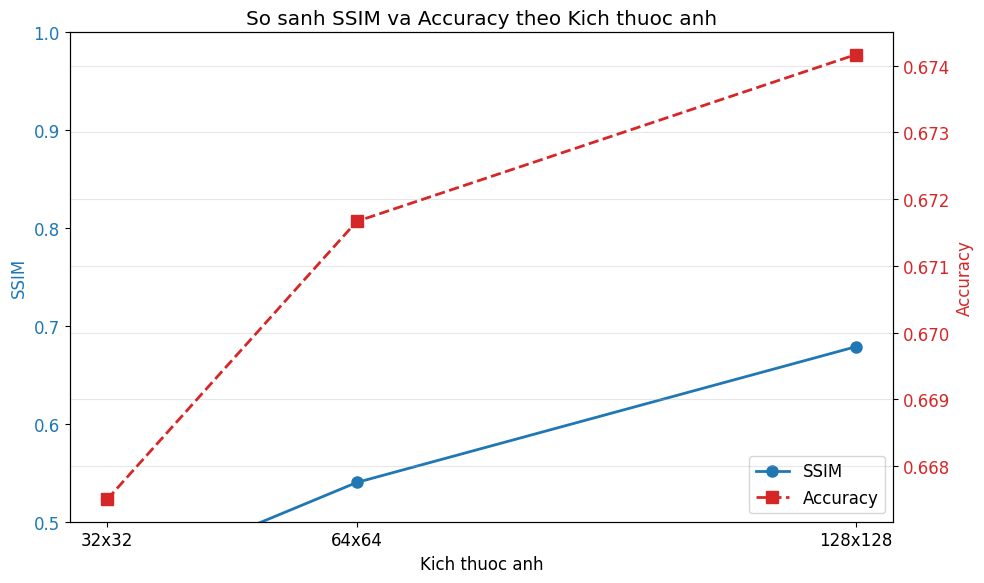

In [ ]:
# Vẽ biểu đồ kết hợp
fig, ax1 = plt.subplots(figsize=(10, 6))

# Trục tung trái: SSIM
color1 = 'tab:blue'
ax1.set_xlabel('Kich thuoc anh')
ax1.set_ylabel('SSIM', color=color1)
line1 = ax1.plot(resize_sizes, [resize_metrics[s]['ssim_mean'] for s in resize_sizes], 
                  'o-', color=color1, label='SSIM', linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_ylim(0.5, 1.0)

# Trục tung phải: Accuracy
ax2 = ax1.twinx()
color2 = 'tab:red'
ax2.set_ylabel('Accuracy', color=color2)
line2 = ax2.plot(resize_sizes, [resize_results[s]['accuracy'] for s in resize_sizes], 
                  's--', color=color2, label='Accuracy', linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color2)

# Legend và tiêu đề
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='lower right')

plt.title('So sanh SSIM va Accuracy theo Kich thuoc anh')
ax1.set_xticks(resize_sizes)
ax1.set_xticklabels([f"{s}x{s}" for s in resize_sizes])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

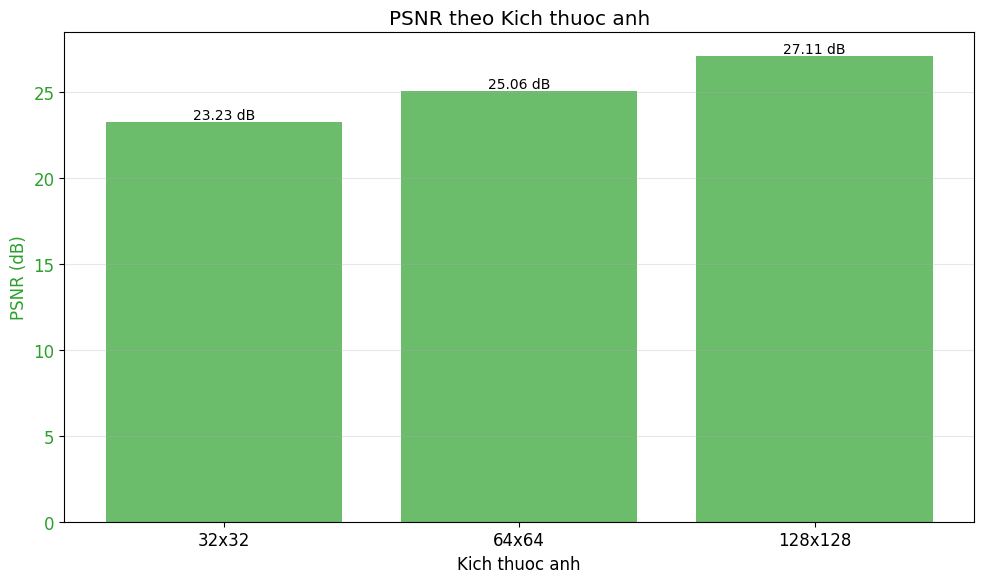

In [ ]:
# Vẽ biểu đồ PSNR
fig, ax = plt.subplots(figsize=(10, 6))

color1 = 'tab:green'
ax.set_xlabel('Kich thuoc anh')
ax.set_ylabel('PSNR (dB)', color=color1)
bars = ax.bar([f"{s}x{s}" for s in resize_sizes], 
               [resize_metrics[s]['psnr_mean'] for s in resize_sizes],
               color=color1, alpha=0.7)
ax.tick_params(axis='y', labelcolor=color1)

# Thêm giá trị lên cột
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f} dB',
            ha='center', va='bottom', fontsize=10)

plt.title('PSNR theo Kich thuoc anh')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

### Nhận xét kết quả Resize

**Kết quả định lượng:**
- `32x32`: Accuracy = **0.6675**, F1 = **0.6618**
- `64x64`: Accuracy = **0.6717**, F1 = **0.6671**
- `128x128`: Accuracy = **0.6742**, F1 = **0.6684**

**Nhận xét chính:**
- Khi tăng kích thước ảnh từ 32 lên 128, hiệu suất tăng nhưng biên độ tăng không lớn (Accuracy chỉ tăng khoảng **0.67% tuyệt đối**).
- `64x64` gần như tiệm cận `128x128` về Accuracy/F1, trong khi chi phí bộ nhớ và thời gian xử lý thấp hơn đáng kể.
- Biểu đồ SSIM/PSNR cho thấy `128x128` giữ chi tiết tốt hơn, nhưng về phân loại thì lợi ích tăng thêm so với `64x64` là không nhiều trong bài toán hiện tại.

In [57]:
# Lưu kết quả tốt nhất (64x64)
best_resize = 64
results_resize = {
    'method': f'Resize {best_resize}x{best_resize}',
    'accuracy': resize_results[best_resize]['accuracy'],
    'f1_score': resize_results[best_resize]['f1_score'],
    'explained_variance': resize_results[best_resize]['explained_variance'],
    'ssim': resize_metrics[best_resize]['ssim_mean'],
    'psnr': resize_metrics[best_resize]['psnr_mean']
}
all_results.append(results_resize)

print(f"Đã chọn kích thước {best_resize}x{best_resize} cho các bước tiếp theo.")

# Giải phóng bộ nhớ
gc.collect()

Đã chọn kích thước 64x64 cho các bước tiếp theo.


12966

---
## 2b. Chuyển đổi không gian màu (Color Space & PCA Explained Variance)

**RGB (Red-Green-Blue):**
- Không gian màu mặc định, 3 kênh màu Red, Green, Blue
- Ánh sáng bị hòa trộn vào cả 3 kênh

**Grayscale:**
- 1 kênh duy nhất (cường độ sáng)
- $Gray = 0.299R + 0.587G + 0.114B$

**HSV (Hue-Saturation-Value):**
- H: Sắc độ (0-179 trong OpenCV)
- S: Độ bão hòa (0-255)
- V: Độ sáng (0-255)
- Tách thông tin màu (H,S) ra khỏi độ sáng (V)

**LAB (CIELAB):**
- L: Lightness (độ sáng)
- a: Trục màu xanh lá - đỏ
- b: Trục màu xanh dương - vàng
- Gần với cách mắt người cảm nhận màu

**Mục tiêu:** Tìm không gian màu có khả năng phân tách đặc trưng vết bệnh ra khỏi nhiễu môi trường (ánh sáng, bóng râm).

In [58]:
print("=" * 60)
print("PHẦN 2b: CHUYỂN ĐỔI KHÔNG GIAN MÀU")
print("=" * 60)

TARGET_SIZE_COLOR = (64, 64)  # Sử dụng kích thước đã chọn

def convert_color_space(image, color_space):
    """
    Chuyển đổi ảnh sang không gian màu khác.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Ảnh RGB (H, W, 3)
    color_space : str
        Tên không gian màu: 'RGB', 'GRAY', 'HSV', 'LAB'
    
    Returns:
    --------
    numpy.ndarray: Ảnh đã chuyển đổi
    """
    if color_space == 'RGB':
        return image
    elif color_space == 'GRAY':
        return cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    elif color_space == 'HSV':
        return cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
    elif color_space == 'LAB':
        return cv2.cvtColor(image, cv2.COLOR_RGB2LAB)
    else:
        raise ValueError(f"Không gian màu chưa được hỗ trợ: {color_space}")


def evaluate_color_space(train_paths, test_paths, train_labels, test_labels,
                         color_space, target_size=(64, 64), batch_size=500, n_components=50):
    """
    Đánh giá hiệu suất phân loại với không gian màu cho trước.
    
    Returns:
    --------
    dict: accuracy, f1_score, explained_variance
    """
    # Xác định số kênh
    if color_space == 'GRAY':
        n_channels = 1
    else:
        n_channels = 3
    
    n_features = target_size[0] * target_size[1] * n_channels
    
    # Fit IncrementalPCA
    ipca = IncrementalPCA(n_components=min(n_components, n_features))
    
    # Fit trên train
    for batch_images, _ in load_images_in_batches(train_paths, target_size, batch_size):
        # Chuyển đổi không gian màu
        converted = []
        for img in batch_images:
            conv_img = convert_color_space(img, color_space)
            converted.append(conv_img)
        converted = np.array(converted)
        
        # Flatten
        if color_space == 'GRAY':
            batch_flat = converted.reshape(len(converted), -1).astype(np.float32) / 255.0
        else:
            batch_flat = flatten_images(converted).astype(np.float32) / 255.0
        
        ipca.partial_fit(batch_flat)
        del batch_images, converted, batch_flat
        gc.collect()
    
    # Transform train
    X_train_list = []
    for batch_images, _ in load_images_in_batches(train_paths, target_size, batch_size):
        converted = np.array([convert_color_space(img, color_space) for img in batch_images])
        if color_space == 'GRAY':
            batch_flat = converted.reshape(len(converted), -1).astype(np.float32) / 255.0
        else:
            batch_flat = flatten_images(converted).astype(np.float32) / 255.0
        X_train_list.append(ipca.transform(batch_flat))
        del batch_images, converted, batch_flat
        gc.collect()
    X_train = np.vstack(X_train_list)
    del X_train_list
    gc.collect()
    
    # Transform test
    X_test_list = []
    for batch_images, _ in load_images_in_batches(test_paths, target_size, batch_size):
        converted = np.array([convert_color_space(img, color_space) for img in batch_images])
        if color_space == 'GRAY':
            batch_flat = converted.reshape(len(converted), -1).astype(np.float32) / 255.0
        else:
            batch_flat = flatten_images(converted).astype(np.float32) / 255.0
        X_test_list.append(ipca.transform(batch_flat))
        del batch_images, converted, batch_flat
        gc.collect()
    X_test = np.vstack(X_test_list)
    del X_test_list
    gc.collect()
    
    # Train và đánh giá
    y_train_adj = train_labels[:len(X_train)]
    y_test_adj = test_labels[:len(X_test)]
    
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_train, y_train_adj)
    y_pred = lr.predict(X_test)
    
    accuracy = accuracy_score(y_test_adj, y_pred)
    f1 = f1_score(y_test_adj, y_pred, average='weighted')
    exp_var = np.sum(ipca.explained_variance_ratio_)
    
    del X_train, X_test, ipca, lr
    gc.collect()
    
    return {'accuracy': accuracy, 'f1_score': f1, 'explained_variance': exp_var}


print("Hàm đánh giá không gian màu đã được định nghĩa!")

PHẦN 2b: CHUYỂN ĐỔI KHÔNG GIAN MÀU
Hàm đánh giá không gian màu đã được định nghĩa!


In [59]:
# Ablation Study: Đánh giá các không gian màu
color_spaces = ['RGB', 'GRAY', 'HSV', 'LAB']
color_results = {}

print("\n" + "-" * 60)
print("ABLATION STUDY: KHÔNG GIAN MÀU")
print("-" * 60)

for cs in color_spaces:
    print(f"\nĐang đánh giá không gian màu {cs}...")
    result = evaluate_color_space(
        train_paths, test_paths, train_labels, test_labels,
        color_space=cs, target_size=TARGET_SIZE_COLOR, 
        batch_size=BATCH_SIZE, n_components=N_COMPONENTS_PCA
    )
    color_results[cs] = result
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1_score']:.4f}")
    print(f"  Explained Variance: {result['explained_variance']*100:.2f}%")


------------------------------------------------------------
ABLATION STUDY: KHÔNG GIAN MÀU
------------------------------------------------------------

Đang đánh giá không gian màu RGB...
  Accuracy: 0.6717
  F1-Score: 0.6671
  Explained Variance: 74.98%

Đang đánh giá không gian màu GRAY...
  Accuracy: 0.5633
  F1-Score: 0.5569
  Explained Variance: 76.43%

Đang đánh giá không gian màu HSV...
  Accuracy: 0.7483
  F1-Score: 0.7456
  Explained Variance: 64.95%

Đang đánh giá không gian màu LAB...
  Accuracy: 0.7017
  F1-Score: 0.6976
  Explained Variance: 72.52%


In [60]:
# Tạo bảng tổng hợp
color_df = pd.DataFrame({
    'Khong gian mau': color_spaces,
    'Phuong sai giai thich (%)': [color_results[cs]['explained_variance']*100 for cs in color_spaces],
    'Accuracy': [color_results[cs]['accuracy'] for cs in color_spaces],
    'F1-Score': [color_results[cs]['f1_score'] for cs in color_spaces]
})

print("\nBẢNG TỔNG HỢP KẾT QUẢ KHÔNG GIAN MÀU:")
print(color_df.to_string(index=False))


BẢNG TỔNG HỢP KẾT QUẢ KHÔNG GIAN MÀU:
Khong gian mau  Phuong sai giai thich (%)  Accuracy  F1-Score
           RGB                  74.978849  0.671667  0.667098
          GRAY                  76.428952  0.563333  0.556934
           HSV                  64.945248  0.748333  0.745592
           LAB                  72.517181  0.701667  0.697614


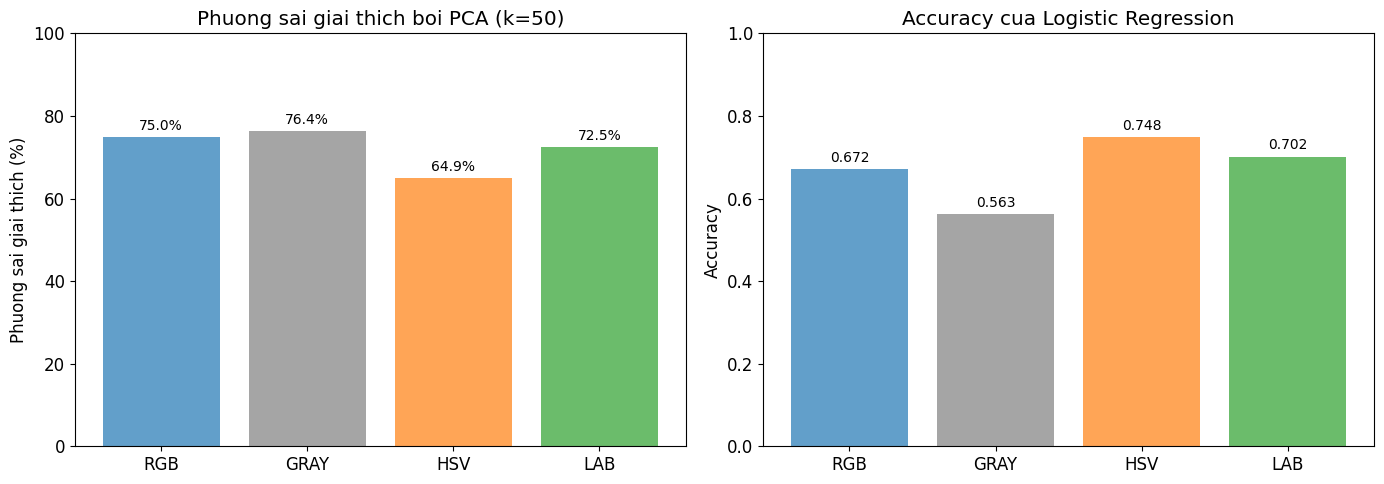

In [ ]:
# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ 1: Phương sai giải thích
colors = ['tab:blue', 'tab:gray', 'tab:orange', 'tab:green']
ax1 = axes[0]
bars1 = ax1.bar(color_spaces, [color_results[cs]['explained_variance']*100 for cs in color_spaces], 
                color=colors, alpha=0.7)
ax1.set_ylabel('Phuong sai giai thich (%)')
ax1.set_title('Phuong sai giai thich boi PCA (k=50)')
ax1.set_ylim(0, 100)
for bar, val in zip(bars1, [color_results[cs]['explained_variance']*100 for cs in color_spaces]):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{val:.1f}%', 
             ha='center', va='bottom', fontsize=10)

# Biểu đồ 2: Accuracy
ax2 = axes[1]
bars2 = ax2.bar(color_spaces, [color_results[cs]['accuracy'] for cs in color_spaces], 
                color=colors, alpha=0.7)
ax2.set_ylabel('Accuracy')
ax2.set_title('Accuracy cua Logistic Regression')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, [color_results[cs]['accuracy'] for cs in color_spaces]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

### Nhận xét kết quả Không gian màu (theo số liệu thực nghiệm)

**Kết quả định lượng:**
- RGB: Accuracy = **0.6717**, F1 = **0.6671**
- GRAY: Accuracy = **0.5633**, F1 = **0.5569**
- HSV: Accuracy = **0.7483**, F1 = **0.7456**
- LAB: Accuracy = **0.7017**, F1 = **0.6976**

**Nhận xét chính:**
- **HSV là tốt nhất**, vượt baseline RGB khoảng **+7.66% Accuracy tuyệt đối** (0.7483 so với 0.6717), đây là cải thiện lớn nhất trong các kỹ thuật đã thử.
- GRAY giảm mạnh hiệu suất do mất thông tin màu đặc trưng của triệu chứng bệnh lá.
- LAB cải thiện so với RGB nhưng vẫn kém HSV, cho thấy trong bộ dữ liệu này việc biểu diễn màu theo HSV giúp tách đặc trưng bệnh rõ hơn.

**Ý nghĩa:**
- Kết quả củng cố giả thuyết rằng đặc trưng màu của vùng bệnh là tín hiệu quan trọng; do đó giữ và biểu diễn màu đúng cách quan trọng hơn việc chỉ tăng kích thước ảnh.

In [62]:
# Chọn không gian màu tốt nhất
best_color_space = max(color_results, key=lambda x: color_results[x]['accuracy'])
results_color = {
    'method': f'Color Space: {best_color_space}',
    'accuracy': color_results[best_color_space]['accuracy'],
    'f1_score': color_results[best_color_space]['f1_score'],
    'explained_variance': color_results[best_color_space]['explained_variance']
}
all_results.append(results_color)

print(f"Không gian màu tốt nhất: {best_color_space}")
print(f"Accuracy: {color_results[best_color_space]['accuracy']:.4f}")

gc.collect()

Không gian màu tốt nhất: HSV
Accuracy: 0.7483


16983

---
## 2c. Chuẩn hóa (Normalization & KS Test)

### Lý thuyết:

**1. Min-Max Scaling [0, 1]:**
$$X_{norm} = \frac{X}{255}$$
- Đưa giá trị pixel về khoảng [0, 1]

**2. Min-Max Scaling [-1, 1]:**
$$X_{norm} = \frac{X}{127.5} - 1$$
- Đưa giá trị pixel về khoảng [-1, 1]

**3. Global Z-score:**
$$X_{norm} = \frac{X - \mu_{global}}{\sigma_{global}}$$
- Chuẩn hóa theo mean và std của toàn bộ dataset

**4. Per-channel Z-score:**
$$X_{norm}^{(c)} = \frac{X^{(c)} - \mu_c}{\sigma_c}$$
- Chuẩn hóa riêng từng kênh màu (R, G, B)
- Cân bằng lại cường độ sáng giữa các kênh

**Kiểm định KS (Kolmogorov-Smirnov):**
- So sánh phân phối dữ liệu với phân phối chuẩn N(0,1)
- KS statistic càng nhỏ, p-value càng lớn => dữ liệu càng gần phân phối chuẩn

In [63]:
print("=" * 60)
print("PHẦN 2c: CHUẨN HÓA ẢNH (NORMALIZATION)")
print("=" * 60)

# Tính mean và std của dữ liệu train
print("\nĐang tính mean và std của dữ liệu train...")

pixel_sum = np.zeros(3, dtype=np.float64)
pixel_sq_sum = np.zeros(3, dtype=np.float64)
pixel_count = 0

for batch_images, _ in load_images_in_batches(train_paths, TARGET_SIZE_COLOR, BATCH_SIZE):
    batch_float = batch_images.astype(np.float64)
    pixel_sum += batch_float.sum(axis=(0, 1, 2))
    pixel_sq_sum += (batch_float ** 2).sum(axis=(0, 1, 2))
    pixel_count += batch_float.shape[0] * batch_float.shape[1] * batch_float.shape[2]
    del batch_images, batch_float
    gc.collect()

# Mean và std cho từng kênh
channel_mean = pixel_sum / pixel_count
channel_std = np.sqrt(pixel_sq_sum / pixel_count - channel_mean ** 2)

# Mean và std global
global_mean = np.mean(channel_mean)
global_std = np.mean(channel_std)

print(f"\nChannel means (R, G, B): {channel_mean}")
print(f"Channel stds (R, G, B): {channel_std}")
print(f"Global mean: {global_mean:.2f}")
print(f"Global std: {global_std:.2f}")

PHẦN 2c: CHUẨN HÓA ẢNH (NORMALIZATION)

Đang tính mean và std của dữ liệu train...

Channel means (R, G, B): [111.9819752  116.17725856 106.14135361]
Channel stds (R, G, B): [48.89088061 44.10338199 51.5419227 ]
Global mean: 111.43
Global std: 48.18


In [64]:
def apply_normalization(images, method, channel_mean=None, channel_std=None, global_mean=None, global_std=None):
    """
    Áp dụng phương pháp chuẩn hóa cho mảng ảnh.
    
    Parameters:
    -----------
    images : numpy.ndarray
        Mảng ảnh (N, H, W, C)
    method : str
        Phương pháp: 'minmax_01', 'minmax_11', 'zscore_global', 'zscore_channel'
    
    Returns:
    --------
    numpy.ndarray: Mảng ảnh đã chuẩn hóa
    """
    images = images.astype(np.float32)
    
    if method == 'minmax_01':
        return images / 255.0
    elif method == 'minmax_11':
        return (images / 127.5) - 1.0
    elif method == 'zscore_global':
        return (images - global_mean) / global_std
    elif method == 'zscore_channel':
        return (images - channel_mean) / channel_std
    else:
        raise ValueError(f"Phương pháp chưa được hỗ trợ: {method}")


def evaluate_normalization(train_paths, test_paths, train_labels, test_labels,
                           norm_method, channel_mean, channel_std, global_mean, global_std,
                           target_size=(64, 64), batch_size=500, n_components=50):
    """
    Đánh giá hiệu suất với phương pháp chuẩn hóa cho trước.
    """
    ipca = IncrementalPCA(n_components=n_components)
    
    # Fit IncrementalPCA
    for batch_images, _ in load_images_in_batches(train_paths, target_size, batch_size):
        batch_norm = apply_normalization(batch_images, norm_method, 
                                          channel_mean, channel_std, global_mean, global_std)
        batch_flat = flatten_images(batch_norm)
        ipca.partial_fit(batch_flat)
        del batch_images, batch_norm, batch_flat
        gc.collect()
    
    # Transform train
    X_train_list = []
    for batch_images, _ in load_images_in_batches(train_paths, target_size, batch_size):
        batch_norm = apply_normalization(batch_images, norm_method,
                                          channel_mean, channel_std, global_mean, global_std)
        batch_flat = flatten_images(batch_norm)
        X_train_list.append(ipca.transform(batch_flat))
        del batch_images, batch_norm, batch_flat
        gc.collect()
    X_train = np.vstack(X_train_list)
    del X_train_list
    gc.collect()
    
    # Transform test
    X_test_list = []
    for batch_images, _ in load_images_in_batches(test_paths, target_size, batch_size):
        batch_norm = apply_normalization(batch_images, norm_method,
                                          channel_mean, channel_std, global_mean, global_std)
        batch_flat = flatten_images(batch_norm)
        X_test_list.append(ipca.transform(batch_flat))
        del batch_images, batch_norm, batch_flat
        gc.collect()
    X_test = np.vstack(X_test_list)
    del X_test_list
    gc.collect()
    
    # Train và đánh giá
    y_train_adj = train_labels[:len(X_train)]
    y_test_adj = test_labels[:len(X_test)]
    
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_train, y_train_adj)
    y_pred = lr.predict(X_test)
    
    accuracy = accuracy_score(y_test_adj, y_pred)
    f1 = f1_score(y_test_adj, y_pred, average='weighted')
    exp_var = np.sum(ipca.explained_variance_ratio_)
    
    del X_train, X_test, ipca, lr
    gc.collect()
    
    return {'accuracy': accuracy, 'f1_score': f1, 'explained_variance': exp_var}


print("Hàm đánh giá chuẩn hóa đã được định nghĩa!")

Hàm đánh giá chuẩn hóa đã được định nghĩa!


In [65]:
# Kiểm định KS Test cho các phương pháp Z-score
print("\n" + "-" * 60)
print("KIỂM ĐỊNH KS (KOLMOGOROV-SMIRNOV TEST)")
print("-" * 60)

# Lấy mẫu ảnh để kiểm định
sample_size_ks = 1000
sample_indices_ks = np.random.choice(len(train_paths), min(sample_size_ks, len(train_paths)), replace=False)
sample_paths_ks = [train_paths[i] for i in sample_indices_ks]

# Đọc mẫu ảnh
sample_images = []
for path in sample_paths_ks:
    img = load_and_resize_image(path, TARGET_SIZE_COLOR)
    if img is not None:
        sample_images.append(img)
sample_images = np.array(sample_images)

print(f"Số ảnh mẫu cho KS test: {len(sample_images)}")

# Tính KS test cho Z-score global
norm_global = apply_normalization(sample_images, 'zscore_global', 
                                   channel_mean, channel_std, global_mean, global_std)
flat_global = flatten_images(norm_global).flatten()
ks_stat_global, p_value_global = kstest(flat_global, 'norm')

print(f"\nGlobal Z-score:")
print(f"  Mean: {np.mean(flat_global):.6f}")
print(f"  Std: {np.std(flat_global):.6f}")
print(f"  KS Statistic: {ks_stat_global:.6f}")
print(f"  p-value: {p_value_global:.6e}")

del norm_global, flat_global
gc.collect()

# Tính KS test cho Z-score per-channel
norm_channel = apply_normalization(sample_images, 'zscore_channel',
                                    channel_mean, channel_std, global_mean, global_std)
flat_channel = flatten_images(norm_channel).flatten()
ks_stat_channel, p_value_channel = kstest(flat_channel, 'norm')

print(f"\nPer-channel Z-score:")
print(f"  Mean: {np.mean(flat_channel):.6f}")
print(f"  Std: {np.std(flat_channel):.6f}")
print(f"  KS Statistic: {ks_stat_channel:.6f}")
print(f"  p-value: {p_value_channel:.6e}")

del norm_channel, flat_channel, sample_images
gc.collect()


------------------------------------------------------------
KIỂM ĐỊNH KS (KOLMOGOROV-SMIRNOV TEST)
------------------------------------------------------------
Số ảnh mẫu cho KS test: 1000

Global Z-score:
  Mean: -0.006580
  Std: 0.998228
  KS Statistic: 0.050326
  p-value: 0.000000e+00

Per-channel Z-score:
  Mean: -0.006632
  Std: 0.992684
  KS Statistic: 0.043566
  p-value: 0.000000e+00


0

In [66]:
# Ablation Study: Đánh giá các phương pháp chuẩn hóa
norm_methods = ['minmax_01', 'minmax_11', 'zscore_global', 'zscore_channel']
norm_names = ['Min-Max [0,1]', 'Min-Max [-1,1]', 'Z-score Global', 'Z-score Per-channel']
norm_results = {}

print("\n" + "-" * 60)
print("ABLATION STUDY: PHƯƠNG PHÁP CHUẨN HÓA")
print("-" * 60)

for method, name in zip(norm_methods, norm_names):
    print(f"\nĐang đánh giá {name}...")
    result = evaluate_normalization(
        train_paths, test_paths, train_labels, test_labels,
        norm_method=method, 
        channel_mean=channel_mean, channel_std=channel_std,
        global_mean=global_mean, global_std=global_std,
        target_size=TARGET_SIZE_COLOR, batch_size=BATCH_SIZE, n_components=N_COMPONENTS_PCA
    )
    norm_results[method] = result
    print(f"  Accuracy: {result['accuracy']:.4f}")
    print(f"  F1-Score: {result['f1_score']:.4f}")


------------------------------------------------------------
ABLATION STUDY: PHƯƠNG PHÁP CHUẨN HÓA
------------------------------------------------------------

Đang đánh giá Min-Max [0,1]...
  Accuracy: 0.6717
  F1-Score: 0.6671

Đang đánh giá Min-Max [-1,1]...
  Accuracy: 0.6717
  F1-Score: 0.6671

Đang đánh giá Z-score Global...
  Accuracy: 0.6717
  F1-Score: 0.6671

Đang đánh giá Z-score Per-channel...
  Accuracy: 0.6725
  F1-Score: 0.6681


In [67]:
# Tạo bảng tổng hợp kết quả
ks_stats = ['-', '-', f'{ks_stat_global:.6f}', f'{ks_stat_channel:.6f}']
p_values = ['-', '-', f'{p_value_global:.2e}', f'{p_value_channel:.2e}']

norm_df = pd.DataFrame({
    'Phuong phap': norm_names,
    'KS Statistic': ks_stats,
    'p-value': p_values,
    'Accuracy': [norm_results[m]['accuracy'] for m in norm_methods],
    'F1-Score': [norm_results[m]['f1_score'] for m in norm_methods]
})

print("\nBẢNG TỔNG HỢP KẾT QUẢ CHUẨN HÓA:")
print(norm_df.to_string(index=False))


BẢNG TỔNG HỢP KẾT QUẢ CHUẨN HÓA:
        Phuong phap KS Statistic  p-value  Accuracy  F1-Score
      Min-Max [0,1]            -        -  0.671667  0.667098
     Min-Max [-1,1]            -        -  0.671667  0.667098
     Z-score Global     0.050326 0.00e+00  0.671667  0.667098
Z-score Per-channel     0.043566 0.00e+00  0.672500  0.668098


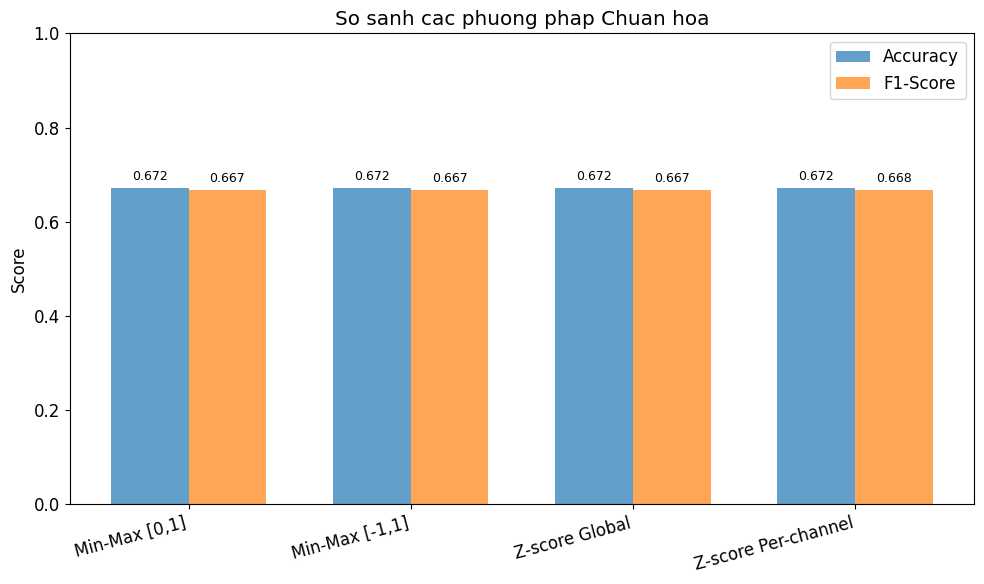

In [ ]:
# Vẽ biểu đồ so sánh
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(norm_names))
width = 0.35

bars1 = ax.bar(x - width/2, [norm_results[m]['accuracy'] for m in norm_methods], 
               width, label='Accuracy', color='tab:blue', alpha=0.7)
bars2 = ax.bar(x + width/2, [norm_results[m]['f1_score'] for m in norm_methods], 
               width, label='F1-Score', color='tab:orange', alpha=0.7)

ax.set_ylabel('Score')
ax.set_title('So sanh cac phuong phap Chuan hoa')
ax.set_xticks(x)
ax.set_xticklabels(norm_names, rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1)

# Thêm giá trị lên cột
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

### Nhận xét kết quả Chuẩn hóa (theo số liệu thực nghiệm)

**Kết quả định lượng:**
- Min-Max [0,1]: Accuracy = **0.6717**, F1 = **0.6671**
- Min-Max [-1,1]: Accuracy = **0.6717**, F1 = **0.6671**
- Z-score Global: Accuracy = **0.6717**, F1 = **0.6671**
- Z-score Per-channel: Accuracy = **0.6725**, F1 = **0.6681**

**Nhận xét:**
- Khác biệt giữa các phương pháp chuẩn hóa là **nhỏ**, nhưng Per-channel Z-score vẫn nhỉnh nhất.
- Điều này cho thấy chuẩn hóa không phải yếu tố tạo đột phá trong bài toán này (so với chuyển không gian màu), nhưng vẫn có tác dụng tinh chỉnh hiệu suất.
- KS test giúp giải thích về mặt phân phối dữ liệu; tuy nhiên quyết định cuối cùng vẫn cần dựa trên Accuracy/F1 trên tập kiểm thử.

**Kết luận:**
- Nếu ưu tiên đơn giản và ổn định: Min-Max [0,1].
- Nếu cần tối ưu thêm điểm số: chọn Per-channel Z-score.

In [69]:
# Chọn phương pháp tốt nhất
best_norm_method = max(norm_results, key=lambda x: norm_results[x]['accuracy'])
best_norm_name = norm_names[norm_methods.index(best_norm_method)]

results_norm = {
    'method': f'Normalization: {best_norm_name}',
    'accuracy': norm_results[best_norm_method]['accuracy'],
    'f1_score': norm_results[best_norm_method]['f1_score'],
    'explained_variance': norm_results[best_norm_method]['explained_variance']
}
all_results.append(results_norm)

print(f"Phương pháp chuẩn hóa tốt nhất: {best_norm_name}")
print(f"Accuracy: {norm_results[best_norm_method]['accuracy']:.4f}")

gc.collect()

Phương pháp chuẩn hóa tốt nhất: Z-score Per-channel
Accuracy: 0.6725


17

---
## 2d. Tăng cường dữ liệu (Data Augmentation & t-SNE)

**Data Augmentation** là kỹ thuật sinh thêm dữ liệu từ dữ liệu có sẵn bằng cách áp dụng các phép biến đổi:
1. **Lật ảnh (Flip)**: Lật ngang/dọc
2. **Xoay (Rotation)**: Xoay một góc nhất định
3. **Cắt ngẫu nhiên (Random Crop)**: Cắt một phần ảnh
4. **Thêm nhiễu (Noise)**: Thêm nhiễu Gaussian
5. **Điều chỉnh sáng/tương phản (Brightness/Contrast)**: Thay đổi độ sáng và tương phản

**t-SNE (t-distributed Stochastic Neighbor Embedding):**
- Giảm chiều dữ liệu xuống 2D hoặc 3D để trực quan hóa
- Giữ lại cấu trúc cụm (cluster) của dữ liệu
- Dùng để đánh giá chất lượng augmentation: nếu ảnh augment nằm gần ảnh gốc cùng lớp, augmentation tốt

**Mục tiêu:** Đánh giá xem pipeline augmentation có tạo ra các biến thể đa dạng nhưng vẫn giữ đúng bản chất của lớp hay không.

In [70]:
print("=" * 60)
print("PHẦN 2d: TĂNG CƯỜNG DỮ LIỆU (DATA AUGMENTATION)")
print("=" * 60)

def augment_image(image):
    """
    Áp dụng các phép biến đổi ngẫu nhiên lên ảnh.
    
    Parameters:
    -----------
    image : numpy.ndarray
        Ảnh RGB (H, W, 3)
    
    Returns:
    --------
    numpy.ndarray: Ảnh đã augment
    """
    img = image.copy()
    
    # 1. Horizontal Flip (xác suất 50%)
    if np.random.random() < 0.5:
        img = cv2.flip(img, 1)
    
    # 2. Vertical Flip (xác suất 50%)
    if np.random.random() < 0.5:
        img = cv2.flip(img, 0)
    
    # 3. Xoay ngẫu nhiên +/- 20 độ
    angle = np.random.uniform(-20, 20)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    img = cv2.warpAffine(img, M, (w, h), borderMode=cv2.BORDER_REFLECT)
    
    # 4. Điều chỉnh độ sáng (xác suất 30%)
    if np.random.random() < 0.3:
        brightness = np.random.uniform(0.8, 1.2)
        img = np.clip(img * brightness, 0, 255).astype(np.uint8)
    
    # 5. Thêm nhiễu Gaussian (xác suất 30%)
    if np.random.random() < 0.3:
        noise_sigma = np.random.uniform(10, 30)
        noise = np.random.normal(0, noise_sigma, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)
    
    return img


print("Hàm augment_image đã được định nghĩa!")

PHẦN 2d: TĂNG CƯỜNG DỮ LIỆU (DATA AUGMENTATION)
Hàm augment_image đã được định nghĩa!



Minh họa các phép augmentation:


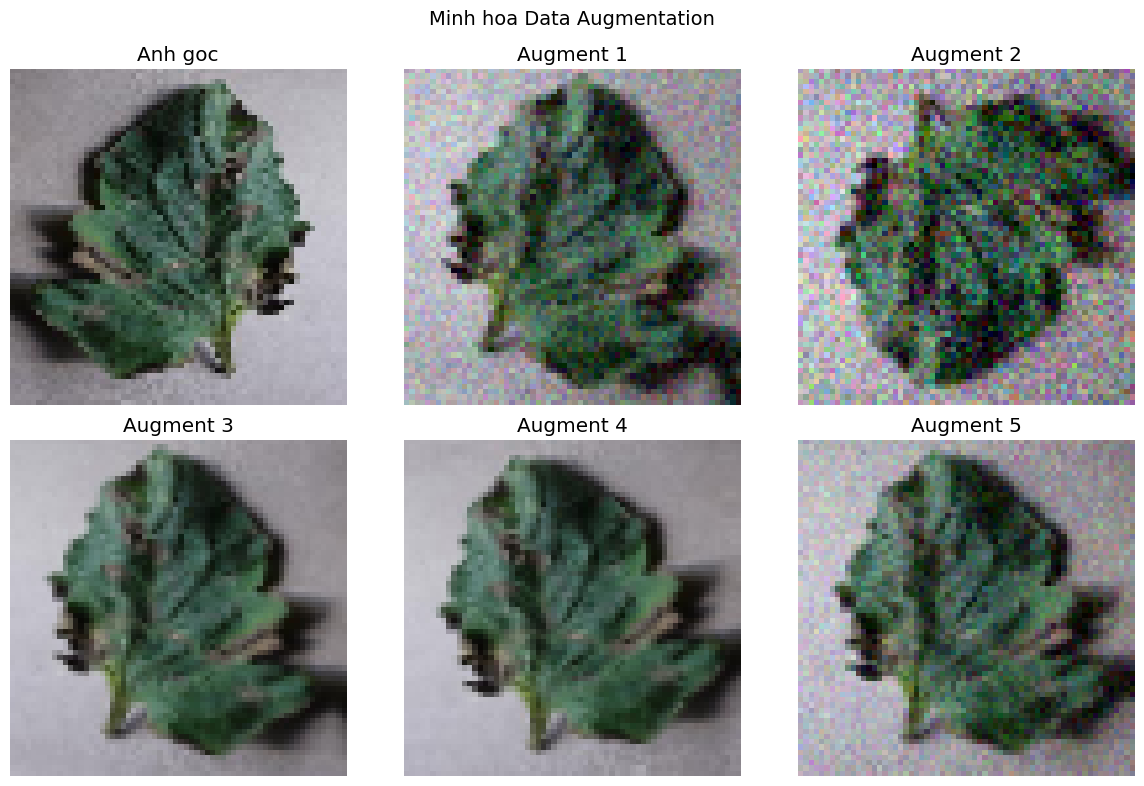

In [ ]:
# Minh họa augmentation
print("\nMinh họa các phép augmentation:")

# Lấy 1 ảnh mẫu
sample_img_path = train_paths[0]
sample_img = load_and_resize_image(sample_img_path, TARGET_SIZE_COLOR)

# Tạo 5 phiên bản augment
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].imshow(sample_img)
axes[0].set_title('Anh goc')
axes[0].axis('off')

for i in range(1, 6):
    aug_img = augment_image(sample_img)
    axes[i].imshow(aug_img)
    axes[i].set_title(f'Augment {i}')
    axes[i].axis('off')

plt.suptitle('Minh hoa Data Augmentation', fontsize=14)
plt.tight_layout()
plt.show()

In [72]:
# Chọn ngẫu nhiên ảnh từ 3 lớp để đánh giá augmentation bằng t-SNE
print("\nChuẩn bị dữ liệu cho t-SNE...")

# Chọn 3 lớp
selected_classes = ['Tomato___healthy', 'Tomato___Bacterial_spot', 'Tomato___Late_blight']
samples_per_class = 150  # 150 ảnh mỗi lớp = 450 ảnh gốc

original_images = []
original_labels = []
augmented_images = []
augmented_labels = []

for class_name in selected_classes:
    # Tìm các ảnh thuộc lớp này
    class_paths = [p for p, l in zip(train_paths, all_labels[:len(train_paths)]) 
                   if l == class_name]
    
    # Lấy mẫu ngẫu nhiên
    np.random.seed(RANDOM_STATE)
    sampled_paths = np.random.choice(class_paths, min(samples_per_class, len(class_paths)), replace=False)
    
    for path in sampled_paths:
        img = load_and_resize_image(path, TARGET_SIZE_COLOR)
        if img is not None:
            original_images.append(img)
            original_labels.append(class_name)
            
            # Tạo ảnh augment tương ứng
            aug_img = augment_image(img)
            augmented_images.append(aug_img)
            augmented_labels.append(class_name)

original_images = np.array(original_images)
augmented_images = np.array(augmented_images)

print(f"Số ảnh gốc: {len(original_images)}")
print(f"Số ảnh augment: {len(augmented_images)}")


Chuẩn bị dữ liệu cho t-SNE...
Số ảnh gốc: 349
Số ảnh augment: 349


In [73]:
# Áp dụng PCA giảm xuống 50 chiều trước khi t-SNE
print("\nÁp dụng PCA và t-SNE...")

# Kết hợp ảnh gốc và augment
all_images_combined = np.vstack([original_images, augmented_images])
all_types = ['Goc'] * len(original_images) + ['Augment'] * len(augmented_images)
all_class_labels = original_labels + augmented_labels

# Flatten và chuẩn hóa
X_combined = flatten_images(all_images_combined).astype(np.float32) / 255.0

print(f"Shape trước PCA: {X_combined.shape}")

# PCA giảm xuống 50 chiều
pca_tsne = PCA(n_components=50, svd_solver='randomized', random_state=RANDOM_STATE)
X_pca = pca_tsne.fit_transform(X_combined)

print(f"Shape sau PCA: {X_pca.shape}")

# t-SNE giảm xuống 2 chiều
tsne = TSNE(n_components=2, random_state=RANDOM_STATE, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

print(f"Shape sau t-SNE: {X_tsne.shape}")

# Giải phóng bộ nhớ
del all_images_combined, X_combined, X_pca
gc.collect()


Áp dụng PCA và t-SNE...
Shape trước PCA: (698, 12288)
Shape sau PCA: (698, 50)
Shape sau t-SNE: (698, 2)


14

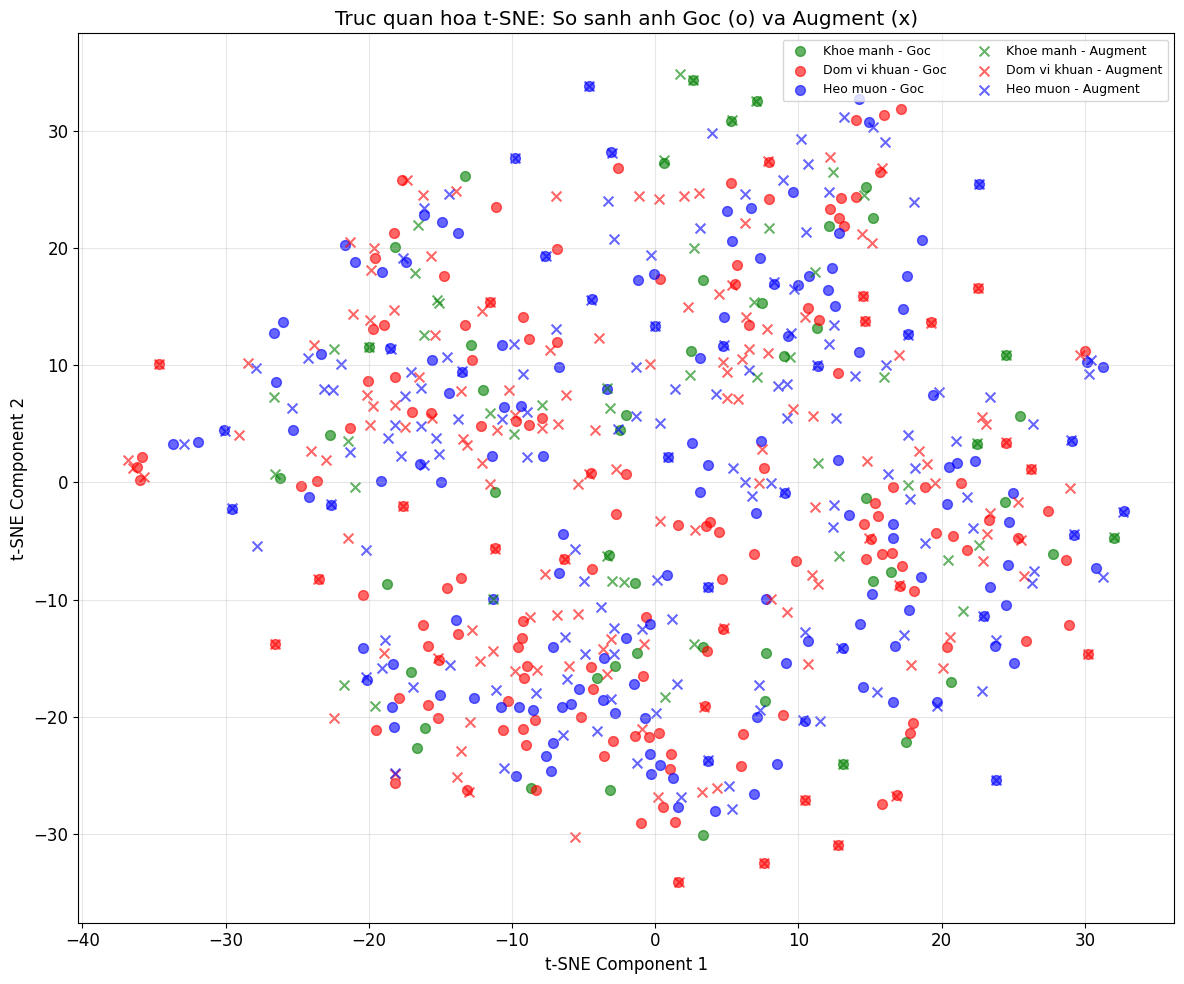

In [ ]:
# Vẽ biểu đồ t-SNE
fig, ax = plt.subplots(figsize=(12, 10))

# Màu cho từng lớp
colors_map = {
    'Tomato___healthy': 'green', 
    'Tomato___Bacterial_spot': 'red', 
    'Tomato___Late_blight': 'blue'
}
class_short_names = {
    'Tomato___healthy': 'Khoe manh', 
    'Tomato___Bacterial_spot': 'Dom vi khuan', 
    'Tomato___Late_blight': 'Heo muon'
}

# Vẽ điểm gốc (hình tròn)
n_original = len(original_images)
for class_name in selected_classes:
    mask = [i for i in range(n_original) if all_class_labels[i] == class_name]
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
               c=colors_map[class_name], marker='o', s=50, alpha=0.6,
               label=f'{class_short_names[class_name]} - Goc')

# Vẽ điểm augment (dấu x)
for class_name in selected_classes:
    mask = [i + n_original for i in range(len(augmented_images)) if all_class_labels[i + n_original] == class_name]
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], 
               c=colors_map[class_name], marker='x', s=50, alpha=0.6,
               label=f'{class_short_names[class_name]} - Augment')

ax.set_xlabel('t-SNE Component 1')
ax.set_ylabel('t-SNE Component 2')
ax.set_title('Truc quan hoa t-SNE: So sanh anh Goc (o) va Augment (x)')
ax.legend(loc='upper right', fontsize=9, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Nhận xét kết quả t-SNE và Data Augmentation

**Từ biểu đồ t-SNE:**
- Nếu các điểm augment (x) bám quanh cụm ảnh gốc (o) cùng màu, augmentation đang tạo biến thiên hợp lý trong cùng lớp.
- Nếu có nhiều điểm augment lấn sâu sang cụm lớp khác, augmentation có thể đang quá mạnh hoặc làm sai lệch tín hiệu phân lớp.

**Từ kết quả định lượng augmentation:**
- Sau augmentation (train size = **14,400**), mô hình đạt Accuracy = **0.6708**, F1 = **0.6655**.
- So với baseline (0.6717 / 0.6671), augmentation hiện tại **không cải thiện** mà giảm nhẹ hiệu suất.

In [75]:
def evaluate_with_augmentation(train_paths, test_paths, train_labels, test_labels,
                                augment_factor=2, target_size=(64, 64), 
                                batch_size=500, n_components=50):
    """
    Đánh giá hiệu suất khi có data augmentation.
    
    Parameters:
    -----------
    augment_factor : int
        Mỗi ảnh gốc sẽ sinh thêm augment_factor ảnh augment
    """
    # Fit IncrementalPCA trên dữ liệu gốc + augment
    ipca = IncrementalPCA(n_components=n_components)
    
    for batch_images, batch_indices in load_images_in_batches(train_paths, target_size, batch_size):
        # Dữ liệu gốc
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        ipca.partial_fit(batch_flat)
        
        # Dữ liệu augment
        for _ in range(augment_factor):
            aug_batch = np.array([augment_image(img) for img in batch_images])
            aug_flat = flatten_images(aug_batch).astype(np.float32) / 255.0
            ipca.partial_fit(aug_flat)
            del aug_batch, aug_flat
        
        del batch_images, batch_flat
        gc.collect()
    
    # Transform train (gốc + augment)
    X_train_list = []
    y_train_list = []
    
    for batch_images, batch_indices in load_images_in_batches(train_paths, target_size, batch_size):
        # Dữ liệu gốc
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        X_train_list.append(ipca.transform(batch_flat))
        for idx in batch_indices:
            if idx < len(train_labels):
                y_train_list.append(train_labels[idx])
        
        # Dữ liệu augment
        for _ in range(augment_factor):
            aug_batch = np.array([augment_image(img) for img in batch_images])
            aug_flat = flatten_images(aug_batch).astype(np.float32) / 255.0
            X_train_list.append(ipca.transform(aug_flat))
            for idx in batch_indices:
                if idx < len(train_labels):
                    y_train_list.append(train_labels[idx])
            del aug_batch, aug_flat
        
        del batch_images, batch_flat
        gc.collect()
    
    X_train = np.vstack(X_train_list)
    y_train = np.array(y_train_list[:len(X_train)])
    del X_train_list, y_train_list
    gc.collect()
    
    # Transform test (chỉ ảnh gốc)
    X_test_list = []
    for batch_images, _ in load_images_in_batches(test_paths, target_size, batch_size):
        batch_flat = flatten_images(batch_images).astype(np.float32) / 255.0
        X_test_list.append(ipca.transform(batch_flat))
        del batch_images, batch_flat
        gc.collect()
    X_test = np.vstack(X_test_list)
    del X_test_list
    gc.collect()
    
    y_test_adj = test_labels[:len(X_test)]
    
    # Train và đánh giá
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, solver='lbfgs')
    lr.fit(X_train, y_train)
    y_pred = lr.predict(X_test)
    
    accuracy = accuracy_score(y_test_adj, y_pred)
    f1 = f1_score(y_test_adj, y_pred, average='weighted')
    exp_var = np.sum(ipca.explained_variance_ratio_)
    
    del X_train, X_test, ipca, lr
    gc.collect()
    
    return {'accuracy': accuracy, 'f1_score': f1, 'explained_variance': exp_var, 'train_size': len(y_train)}


# Đánh giá với augmentation
print("\n" + "-" * 60)
print("ABLATION STUDY: DATA AUGMENTATION")
print("-" * 60)

print("\nĐang đánh giá với Data Augmentation (augment_factor=2)...")
aug_result = evaluate_with_augmentation(
    train_paths, test_paths, train_labels, test_labels,
    augment_factor=2, target_size=TARGET_SIZE_COLOR, 
    batch_size=BATCH_SIZE, n_components=N_COMPONENTS_PCA
)

print(f"\nKết quả:")
print(f"  Kích thước tập train (sau augmentation): {aug_result['train_size']}")
print(f"  Accuracy: {aug_result['accuracy']:.4f}")
print(f"  F1-Score: {aug_result['f1_score']:.4f}")


------------------------------------------------------------
ABLATION STUDY: DATA AUGMENTATION
------------------------------------------------------------

Đang đánh giá với Data Augmentation (augment_factor=2)...

Kết quả:
  Kích thước tập train (sau augmentation): 14400
  Accuracy: 0.6708
  F1-Score: 0.6655


In [76]:
# Lưu kết quả augmentation
results_aug = {
    'method': 'Data Augmentation (x3)',
    'accuracy': aug_result['accuracy'],
    'f1_score': aug_result['f1_score'],
    'explained_variance': aug_result['explained_variance']
}
all_results.append(results_aug)

gc.collect()

0

---
## 3. Tổng kết và So sánh các Kỹ thuật Tiền xử lý

In [77]:
print("=" * 60)
print("TỔNG KẾT KẾT QUẢ")
print("=" * 60)

# Tạo dataframe tổng hợp
results_df = pd.DataFrame(all_results)
results_df['accuracy_pct'] = results_df['accuracy'] * 100
results_df['f1_score_pct'] = results_df['f1_score'] * 100

print("\nBẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ:")
print(results_df[['method', 'accuracy', 'f1_score']].to_string(index=False))

TỔNG KẾT KẾT QUẢ

BẢNG TỔNG HỢP TẤT CẢ KẾT QUẢ:
                               method  accuracy  f1_score
Baseline (64x64, MinMax[0,1], PCA-50)  0.671667  0.667098
                         Resize 64x64  0.671667  0.667098
                     Color Space: HSV  0.748333  0.745592
   Normalization: Z-score Per-channel  0.672500  0.668098
               Data Augmentation (x3)  0.670833  0.665538


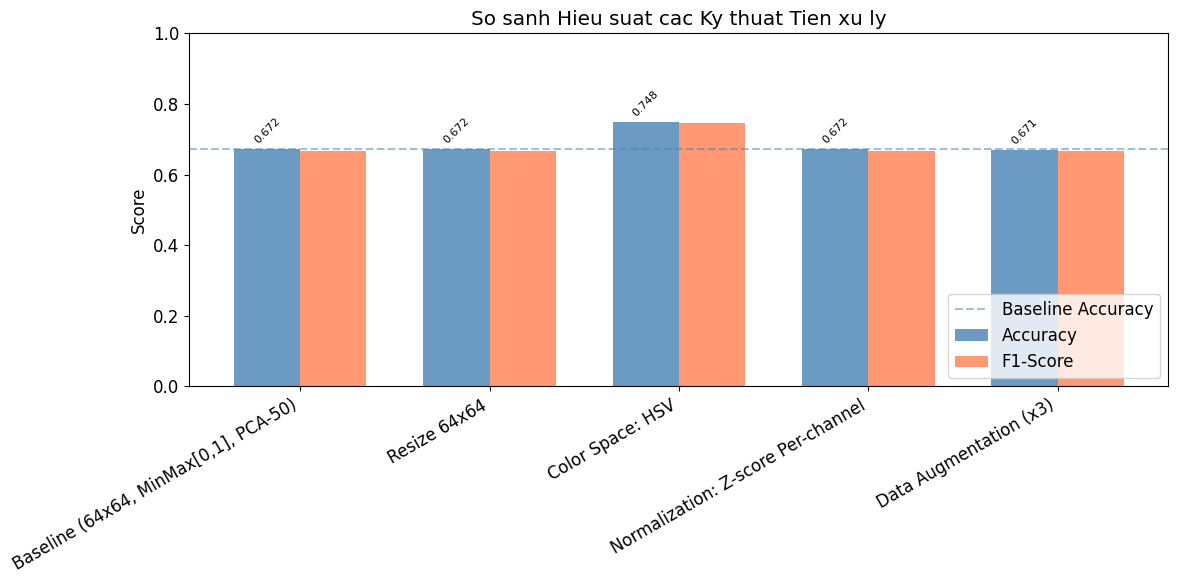

In [ ]:
# Vẽ biểu đồ so sánh tổng hợp
fig, ax = plt.subplots(figsize=(12, 6))

methods = results_df['method'].tolist()
x = np.arange(len(methods))
width = 0.35

bars1 = ax.bar(x - width/2, results_df['accuracy'], width, label='Accuracy', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, results_df['f1_score'], width, label='F1-Score', color='coral', alpha=0.8)

# Thêm đường baseline
ax.axhline(y=results_df.iloc[0]['accuracy'], color='steelblue', linestyle='--', alpha=0.5, label='Baseline Accuracy')

ax.set_ylabel('Score')
ax.set_title('So sanh Hieu suat cac Ky thuat Tien xu ly')
ax.set_xticks(x)
ax.set_xticklabels(methods, rotation=30, ha='right')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)

# Thêm giá trị
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

In [79]:
# Tính sự cải thiện so với baseline
baseline_acc = results_df.iloc[0]['accuracy']

print("\nSỰ CẢI THIỆN SO VỚI BASELINE:")
for idx, row in results_df.iterrows():
    improvement = (row['accuracy'] - baseline_acc) * 100
    sign = '+' if improvement >= 0 else ''
    print(f"  {row['method']}: {sign}{improvement:.2f}%")


SỰ CẢI THIỆN SO VỚI BASELINE:
  Baseline (64x64, MinMax[0,1], PCA-50): +0.00%
  Resize 64x64: +0.00%
  Color Space: HSV: +7.67%
  Normalization: Z-score Per-channel: +0.08%
  Data Augmentation (x3): -0.08%


## Kết luận theo kết quả thực nghiệm

### Xếp hạng hiệu quả các kỹ thuật (theo Accuracy/F1)
- **Tốt nhất:** Color Space HSV với Accuracy = **0.7483**, F1 = **0.7456**.
- **Nhóm trung bình:** Baseline, Resize 64x64, Normalization Per-channel (quanh mức 0.67).
- **Kém nhất trong nhóm thử nghiệm:** Data Augmentation hiện tại (0.6708 / 0.6655), thấp hơn nhẹ so với baseline.

### Kết luận theo từng mục tiêu
- Nếu mục tiêu là **tăng mạnh độ chính xác**, ưu tiên chuyển đổi không gian màu sang **HSV**.
- Nếu mục tiêu là **tiết kiệm tài nguyên**, `64x64` vẫn là lựa chọn cân bằng tốt.
- Nếu mục tiêu là **tối ưu tinh chỉnh**, Per-channel Z-score cho cải thiện nhỏ nhưng ổn định.

In [80]:
# Lưu kết quả cuối cùng ra file
results_df.to_csv('preprocessing_results.csv', index=False)
print("Đã lưu kết quả vào file preprocessing_results.csv")

# Dọn dẹp bộ nhớ
gc.collect()
print("\nHoàn thành!")

Đã lưu kết quả vào file preprocessing_results.csv

Hoàn thành!
